In [1]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
from utilis import Utility, Data, Visualization, Score

In [2]:
from chunk_handle import get_chunk_indices, iter_chunks, compute_global_image_stats, compute_global_label_stats

In [3]:
chunk_dir= "./dataset/chunk_kappa_noise"
indices=np.arange(10)
means, stds=compute_global_image_stats(chunk_dir, indices)
label_scaler=compute_global_label_stats(chunk_dir, indices)

In [4]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize(mean=[means], std=[stds]),   
])
print(f"Image stats (from train set): Mean={means}, Std={stds}")
print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

Image stats (from train set): Mean=-0.00014365838433150202, Std=0.020474925637245178
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


In [5]:
# Simple CNN architecture for parameter estimation

class Simple_CNN(nn.Module):
    def __init__(self, height, width, num_targets):
        super(Simple_CNN, self).__init__()
        # Convolutional layers
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._feature_size = self._get_conv_output_size(height, width)
        
        # Fully connected layers (regressor head)
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets)
        )

    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.conv_stack(dummy_input)
        return int(np.prod(output.size()))

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.fc_stack(x)
        means = x[:, :2]
        log_sigmas = x[:, 2:]    # Predict log(σ) to ensure positivity
        sigmas = torch.exp(log_sigmas)
        return means, sigmas     # Note that means and sigmas here have to be rescaled properly due to standardization

In [6]:
def KL_div_posterior_loss(pred_means, pred_sigmas, truths):
    """
    A KL divergence loss function that directly optimizes the score function
    
    Inputs:
    - pred_means:   2D tensor (batch_size, 2)
    - pred_sigmas:  2D tensor (batch_size, 2) 
    - truths:       2D tensor (batch_size, 2)
    """
    
    residuals_sq = (pred_means - truths)**2  
    
    loss_terms = residuals_sq / (pred_sigmas**2)
    loss_sum = torch.sum(loss_terms, dim=1)
    
    log_sigma_terms = torch.sum(torch.log(pred_sigmas**2), dim=1)
    loss = torch.mean(loss_sum + log_sigma_terms)
    
    return loss

In [ ]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Training")
    for X, y in pbar:
        X, y = X.to(device), y.to(device)

        # Forward pass
        pred_means, pred_sigmas= model(X)
        gt_means, gt_sigmas = y[:, :2], y[:, 2:]
        loss_mean = loss_fn(pred_means, gt_means)
        loss_sigma = loss_fn(pred_sigmas, gt_sigmas)
        loss = loss_mean + loss_sigma

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred_means, pred_sigmas = model(X)
            gt_means, gt_sigmas = y[:, :2], y[:, 2:]
            loss_mean = loss_fn(pred_means, gt_means)
            loss_sigma = loss_fn(pred_sigmas, gt_sigmas)
            loss = loss_mean + loss_sigma
            total_loss += loss.item()
            
    return total_loss / len(dataloader)

In [8]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
        if self.transform:
            image = self.transform(image) 
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return image, label
        else:
            return image

In [9]:
import os
import numpy as np
from typing import Optional, Tuple, Generator, Dict, Any
from sklearn.model_selection import train_test_split  # For splitting; assumes scikit-learn is available
# Assuming PyTorch for model training; adjust if using another framework
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms



class Config:
    IMG_HEIGHT = 1424
    IMG_WIDTH = 176
    
    # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
    NUM_TARGETS = 4

    # Training hyperparameters
    BATCH_SIZE = 64
    EPOCHS = 1
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting
    
    DEVICE = "mps" if torch.mps.is_available() else "cpu"
    MODEL_SAVE_PATH = "./best_model.pth"


def incremental_train(model: nn.Module, 
                      config: Config,
                      optimizer: optim.Optimizer, 
                      criterion: nn.Module, 
                      chunk_dir: str,
                      split_ratio: float = 0.8,
                      epochs_per_chunk: int = 1,
                      device: str = 'mps' if torch.mps.is_available() else 'cpu',
                      verbose: bool = False) -> Dict[str, Any]:
    """
    Incrementally train a PyTorch model across chunks without loading the entire dataset.
    
    - Loads one chunk at a time.
    - Splits each chunk into train/test sets.
    - Trains the model on the train set using batches (for memory efficiency within chunk).
    - Accumulates training history.
    - Returns a summary dict with loss history, etc.
    
    Args:
        model: PyTorch model (nn.Module).
        optimizer: PyTorch optimizer.
        criterion: Loss function (e.g., nn.MSELoss()).
        chunk_dir: Directory containing chunk files.
        split_ratio: Fraction for train split (e.g., 0.8).
        batch_size: Batch size for training.
        epochs_per_chunk: Number of epochs to train on each chunk.
        device: Device to train on ('cuda' or 'cpu').
        verbose: If True, print progress.
    
    Returns:
        Dict with 'train_losses' (list of lists: per-chunk losses), 'total_epochs', etc.
    """
    device=config.DEVICE
    model.to(device)
    model.train()
    total_val_datasets = []
    
    indices = get_chunk_indices(chunk_dir)
    train_losses = []  # List of lists: losses per epoch per chunk
    total_samples = 0
    
    for epoch in range(config.EPOCHS):
        print(f"Epoch {epoch+1}/{config.EPOCHS}")
        for chunk_idx in indices:
            if verbose:
                print(f"Processing chunk {chunk_idx}...")
            
            # Load single chunk (assumes it fits in memory)
            noisy_chunk, label_chunk, _ = next(iter_chunks(chunk_dir, indices=[chunk_idx]))
            
            # Split into train/test (stratified if labels are categorical; here simple split)
            Nsys = noisy_chunk.shape[1]
            print(f"NP_idx : {Nsys}")
            NP_idx = np.arange(Nsys)   
            shape = noisy_chunk.shape[2:]
            print('n samples in chunk (H,W):', shape)
            split_fraction = 1-split_ratio     # Set the fraction of data you want to split (between 0 and 1)
            seed = 113               # Define your random seed for reproducible results

            train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction,
                                                        random_state=seed)

            noisy_kappa_train = noisy_chunk[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), 1424, 176)
            label_train = label_chunk[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
            noisy_kappa_val = noisy_chunk[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), 1424, 176)
            label_val = label_chunk[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)

            Ntrain = label_train.shape[0]*label_train.shape[1]
            Nval = label_val.shape[0]*label_val.shape[1]
            print(f'Shape of the split training data = {noisy_kappa_train.shape}')
            print(f'Shape of the split validation data = {noisy_kappa_val.shape}')

            print(f'Shape of the split training labels = {label_train.shape}')
            print(f'Shape of the split validation labels = {label_val.shape}')
            # Reshape the data for CNN (use tuple unpacking for the image shape)
            # shape is a tuple like (H, W)
            X_train = noisy_kappa_train.reshape(Ntrain, *shape)
            X_val = noisy_kappa_val.reshape(Nval, *shape)


            # Here, we ignore the nuisance parameters and only keep the first 2 cosmological parameters
            label_dim = label_train.shape[2]
            y_train = label_train.reshape(Ntrain, label_dim)[:, :2]
            y_val = label_val.reshape(Nval, label_dim)[:, :2]
            # Compute the means and stds of the training images (for standardizing the data)

            # means = np.mean(X_train, dtype=np.float32)
            # stds = np.std(X_train, dtype=np.float32)

            # transform = transforms.Compose([
            #     transforms.ToTensor(),     
            #     transforms.Normalize(mean=[means], std=[stds]),   
            # ])
            # print(f"Image stats (from train set): Mean={means}, Std={stds}")

            # Label standardization
            # label_scaler = StandardScaler()
            y_train_scaled = label_scaler.transform(y_train)
            y_val_scaled = label_scaler.transform(y_val)
            print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")
            train_dataset = CosmologyDataset(
                data=X_train, 
                labels=y_train_scaled,
                transform=transform
            )
            val_dataset = CosmologyDataset(
                data=X_val, 
                labels=y_val_scaled,
                transform=transform
            )
            if epoch == 0:
                total_val_datasets.append(val_dataset)


            train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True) 
            val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

            scheduler = ReduceLROnPlateau(optimizer,
                                    mode='min',
                                    factor=0.5,
                                    patience=5)
            best_val_loss = float('inf')
            start_time = time.time()
            for epoch_chunk in range(epochs_per_chunk):
                train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
                val_loss = validate_epoch(model, val_loader, criterion, config.DEVICE)
            
                scheduler.step(val_loss)    
                print(f"Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
                
                # Save the best model based on validation loss
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
                    print(f"  -> New best model saved to {config.MODEL_SAVE_PATH}")

            end_time = time.time()
            print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
            
            model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True)) # Directly load the best model
    return {
        'train_losses': train_losses,
        'total_val_datasets': total_val_datasets,
        'total_epochs': config.EPOCHS,
        'total_samples': total_samples
    }


In [27]:
config = Config()
model=Simple_CNN(config.IMG_HEIGHT, config.IMG_WIDTH, config.NUM_TARGETS)
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

# criterion = KL_div_posterior_loss  # Custom loss function defined earlier
criterion = nn.MSELoss()  # Mean Squared Error loss for regression
history = incremental_train(model, config, optimizer, criterion, './dataset/chunk_kappa_noise', epochs_per_chunk=1, verbose=True)

Epoch 1/1
Processing chunk 0...
NP_idx : 256
n samples in chunk (H,W): (1424, 176)
NP_idx : 256
n samples in chunk (H,W): (1424, 176)
Shape of the split training data = (11, 204, 1424, 176)
Shape of the split validation data = (11, 52, 1424, 176)
Shape of the split training labels = (11, 204, 5)
Shape of the split validation labels = (11, 52, 5)
Shape of the split training data = (11, 204, 1424, 176)
Shape of the split validation data = (11, 52, 1424, 176)
Shape of the split training labels = (11, 204, 5)
Shape of the split validation labels = (11, 52, 5)
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


Training:   0%|          | 0/36 [00:01<?, ?it/s]



TypeError: MSELoss.forward() takes 3 positional arguments but 4 were given

In [11]:
total_val_datasets = history['total_val_datasets']
train_losses = history['train_losses']
total_samples = history['total_samples']
total_epochs = history['total_epochs']
if total_val_datasets:
    all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
    all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
    concatenated_val_dataset = CosmologyDataset(
        data=all_val_data,
        labels=all_val_labels,
        transform=transform # Use transform from first dataset
    )
    val_loader = DataLoader(
        concatenated_val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )
else:
    concatenated_val_loader = None
    print("No validation datasets to concatenate.")

In [12]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for X, _ in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean_val = np.concatenate(means_pred_list, axis=0)
mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

Validating: 100%|██████████| 83/83 [00:41<00:00,  2.01it/s]



In [13]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean_val - errorbar_val < 0
errorbar_val[negative_mask] = mean_val[negative_mask]

In [17]:
validation_score = Score._score_phase1(
    true_cosmo=all_val_labels,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))

averaged score: -3285.116326434373
averaged error bar: [0.0893126  0.05908732]


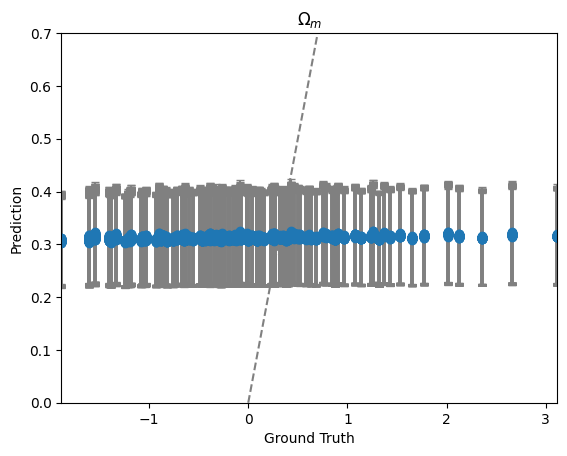

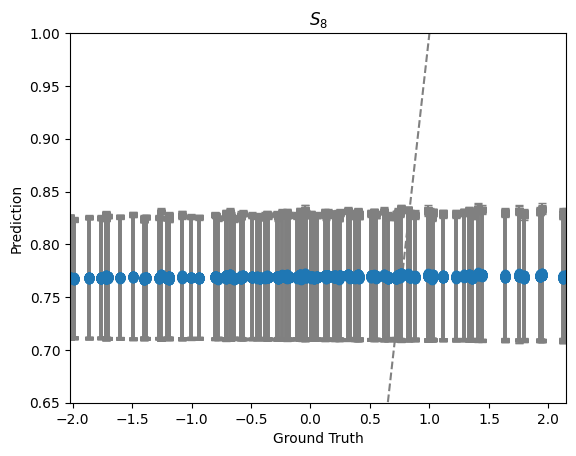

In [19]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels

plt.errorbar(all_val_labels[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels[:,0]), sorted(all_val_labels[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels[:,0]), np.max(all_val_labels[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(all_val_labels[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels[:,1]), sorted(all_val_labels[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels[:,1]), np.max(all_val_labels[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [20]:
# Initialize Data class object
data_obj = Data(data_dir="./dataset", USE_PUBLIC_DATASET=True)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

Loading WIDE12H_bin2_2arcmin_kappa.npy: 100%|██████████| 11/11 [00:52<00:00,  4.79s/it]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy:   0%|          | 0/40 [00:00<?, ?it/s]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy: 100%|██████████| 40/40 [00:05<00:00,  6.88it/s]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy: 100%|██████████| 40/40 [00:05<00:00,  6.88it/s]


In [22]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [23]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [24]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for X in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean = np.concatenate(means_pred_list, axis=0)
mean = label_scaler.inverse_transform(mean)          # inverse transform

errorbar = np.concatenate(sigmas_pred_list, axis=0)
errorbar = errorbar*label_scaler.var_**0.5           # rescale by the training label std

Inference on the test set: 100%|██████████| 63/63 [00:06<00:00,  9.29it/s]



In [25]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean - errorbar < 0
errorbar[negative_mask] = mean[negative_mask]

In [26]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_25-09-17-19-55.zip


In [ ]:
# model.eval()
# means_pred_list, sigmas_pred_list = [], []
# pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
# with torch.no_grad():
#     for X, _ in pbar:
#         X = X.to(config.DEVICE)
#         means_pred, sigmas_pred = model(X)         
#         means_pred_list.append(means_pred.cpu().numpy()) 
#         sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
# mean_val = np.concatenate(means_pred_list, axis=0)
# mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

# errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
# errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

In [ ]:
# model.eval()
# means_pred_list, sigmas_pred_list = [], []
# pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
# with torch.no_grad():
#     for X, _ in pbar:
#         X = X.to(config.DEVICE)
#         means_pred, sigmas_pred = model(X)         
#         means_pred_list.append(means_pred.cpu().numpy()) 
#         sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
# mean_val = np.concatenate(means_pred_list, axis=0)
# mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

# errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
# errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std